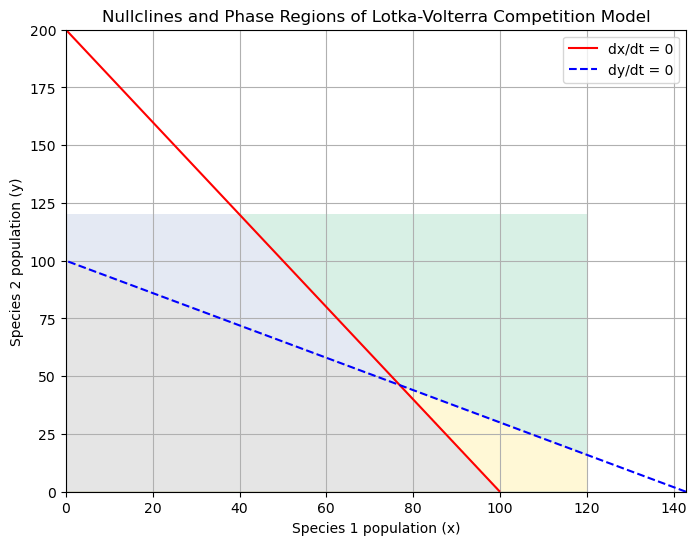

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r1, r2 = 1, 1
K1, K2 = 100, 100
alpha, beta = 0.5, 0.7

# Nullclines:
# dx/dt = 0 -> x = 0 or x + alpha*y = K1
# dy/dt = 0 -> y = 0 or y + beta*x = K2

# Create grid
x = np.linspace(0, K1 * 1.2, 400)
y = np.linspace(0, K2 * 1.2, 400)
X, Y = np.meshgrid(x, y)

# Evaluate dx/dt and dy/dt on the grid
dxdt = r1 * X * (1 - (X + alpha * Y) / K1)
dydt = r2 * Y * (1 - (Y + beta * X) / K2)

# Determine regions where each derivative is positive or negative
region = np.zeros_like(X)

# Encode regions with:
# 0 - both negative
# 1 - dx positive, dy negative
# 2 - dx negative, dy positive
# 3 - both positive
region[(dxdt > 0) & (dydt > 0)] = 3
region[(dxdt > 0) & (dydt < 0)] = 1
region[(dxdt < 0) & (dydt > 0)] = 2

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Shade regions
cmap = plt.get_cmap("Pastel2", 4)
contour = ax.contourf(X, Y, region, levels=[-0.5, 0.5, 1.5, 2.5, 3.5], cmap=cmap, alpha=0.5)

# Plot nullclines
x_nullcline_y = (K1 - x) / alpha
y_nullcline_x = (K2 - y) / beta

# Make sure values within bounds
x_nullcline_y[x_nullcline_y < 0] = np.nan
y_nullcline_x[y_nullcline_x < 0] = np.nan

ax.plot(x, x_nullcline_y, 'r-', label='dx/dt = 0')
ax.plot(y_nullcline_x, y, 'b--', label='dy/dt = 0')

# Labels and legend
ax.set_xlabel("Species 1 population (x)")
ax.set_ylabel("Species 2 population (y)")
ax.set_title("Nullclines and Phase Regions of Lotka-Volterra Competition Model")
ax.legend()
ax.set_xlim(0, K2/beta)
ax.set_ylim(0, K1/alpha)

plt.grid(True)
plt.show()


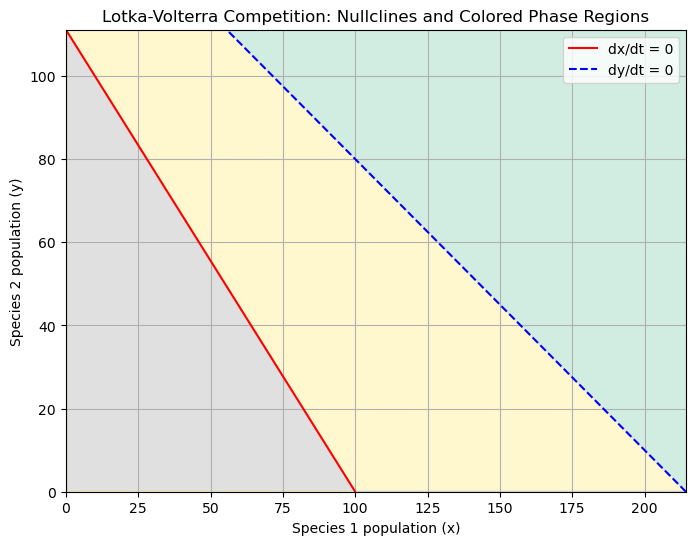

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r1, r2 = 1, 1
K1, K2 = 100, 150
alpha, beta = 0.9, 0.7

# Limits based on nullcline intersections
x_max = K2 / beta
y_max = K1 / alpha

# Create grid
x = np.linspace(0, x_max, 400)
y = np.linspace(0, y_max, 400)
X, Y = np.meshgrid(x, y)

# Evaluate dx/dt and dy/dt on the grid
dxdt = r1 * X * (1 - (X + alpha * Y) / K1)
dydt = r2 * Y * (1 - (Y + beta * X) / K2)

# Define region coloring
region = np.zeros_like(X)
region[(dxdt > 0) & (dydt > 0)] = 3
region[(dxdt > 0) & (dydt < 0)] = 1
region[(dxdt < 0) & (dydt > 0)] = 2

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Shade regions
cmap = plt.get_cmap("Pastel2", 4)
ax.contourf(X, Y, region, levels=[-0.5, 0.5, 1.5, 2.5, 3.5], cmap=cmap, alpha=0.6)

# Nullclines
x_vals = np.linspace(0, x_max, 400)
y_nullcline = (K1 - x_vals) / alpha
y_nullcline[y_nullcline < 0] = np.nan

y_vals = np.linspace(0, y_max, 400)
x_nullcline = (K2 - y_vals) / beta
x_nullcline[x_nullcline < 0] = np.nan

ax.plot(x_vals, y_nullcline, 'r-', label='dx/dt = 0')
ax.plot(x_nullcline, y_vals, 'b--', label='dy/dt = 0')

# Apply the limits
ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)

# Labels and final touches
ax.set_xlabel("Species 1 population (x)")
ax.set_ylabel("Species 2 population (y)")
ax.set_title("Lotka-Volterra Competition: Nullclines and Colored Phase Regions")
ax.legend()
ax.grid(True)

plt.show()


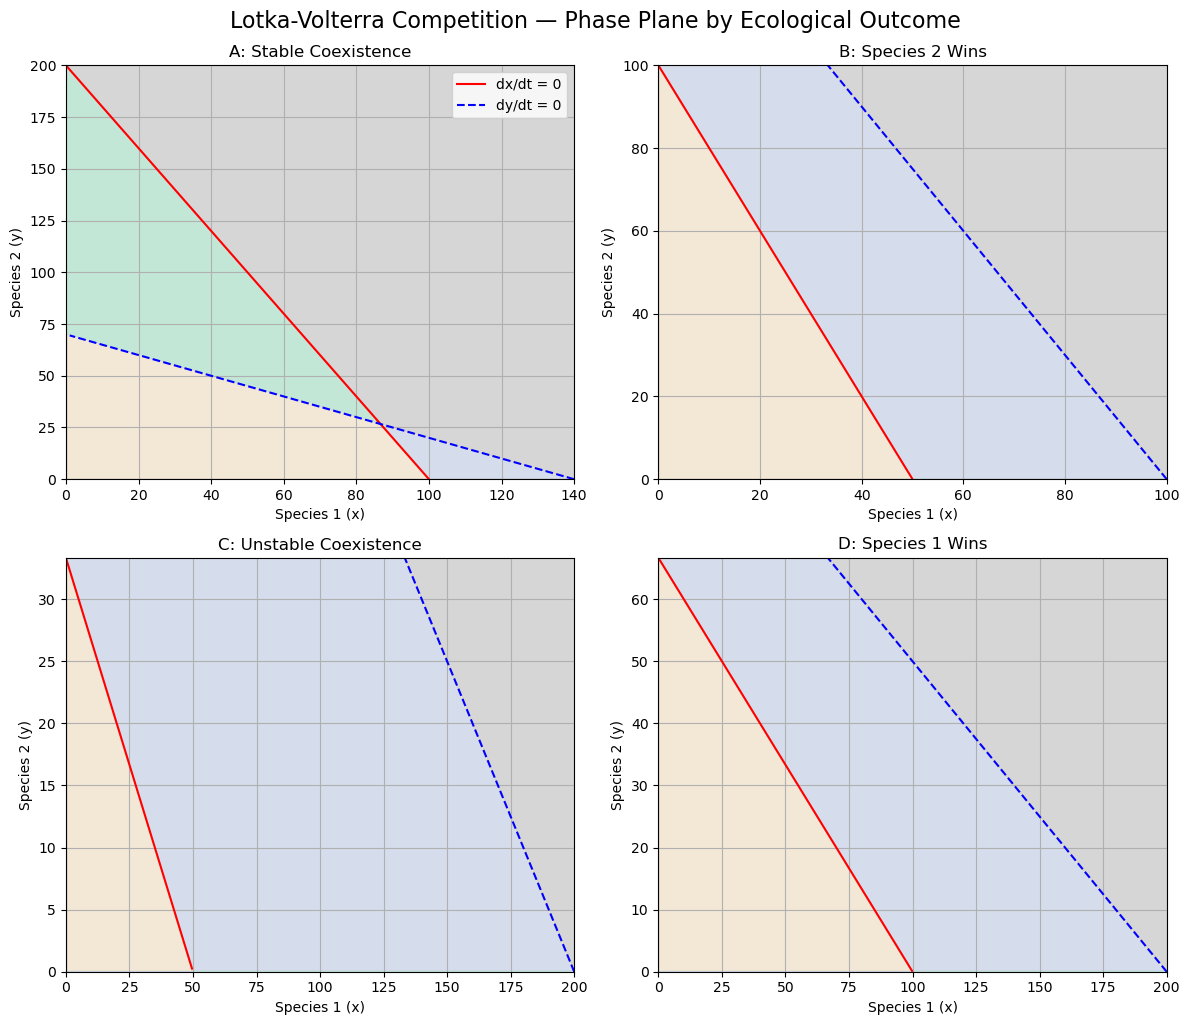

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def plot_clean_case(ax, K1, K2, alpha, beta, title):
    r1 = r2 = 1

    # Set axis limits to capture full nullcline range
    x_max = K2 / beta * 1.1
    y_max = K1 / alpha * 1.1

    x = np.linspace(0, x_max, 400)
    y = np.linspace(0, y_max, 400)
    X, Y = np.meshgrid(x, y)

    # Compute derivatives
    dxdt = r1 * X * (1 - (X + alpha * Y) / K1)
    dydt = r2 * Y * (1 - (Y + beta * X) / K2)

    # Determine region types
    region = np.zeros_like(X)
    region[(dxdt > 0) & (dydt > 0)] = 3
    region[(dxdt > 0) & (dydt < 0)] = 1
    region[(dxdt < 0) & (dydt > 0)] = 2
    region[(dxdt < 0) & (dydt < 0)] = 4

    # Plot shaded regions
    cmap = plt.get_cmap("Pastel2", 5)
    ax.contourf(X, Y, region, levels=[0.5, 1.5, 2.5, 3.5, 4.5], cmap=cmap, alpha=0.8)

    # Nullclines
    x_vals = np.linspace(0, x_max, 400)
    y1_nc = (K1 - x_vals) / alpha
    y1_nc[y1_nc < 0] = np.nan

    y_vals = np.linspace(0, y_max, 400)
    x2_nc = (K2 - y_vals) / beta
    x2_nc[x2_nc < 0] = np.nan

    ax.plot(x_vals, y1_nc, 'r-', label='dx/dt = 0')
    ax.plot(x2_nc, y_vals, 'b--', label='dy/dt = 0')
    ax.set_xlim(0, K2/beta)
    ax.set_ylim(0, K1/alpha)
    ax.set_xlabel("Species 1 (x)")
    ax.set_ylabel("Species 2 (y)")
    ax.set_title(title)
    ax.grid(True)

# Define 4 biological outcome cases
cases = [
    {"K1": 100, "K2": 70, "alpha": 0.5, "beta": 0.5, "title": "A: Stable Coexistence"},
    {"K1": 50,  "K2": 150, "alpha": 0.5, "beta": 1.5, "title": "B: Species 2 Wins"},
    {"K1": 50,  "K2": 100, "alpha": 1.5, "beta": 0.5, "title": "C: Unstable Coexistence"},
    {"K1": 100, "K2": 100,  "alpha": 1.5, "beta": 0.5, "title": "D: Species 1 Wins"}
]

# Plot all cases in a 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, case in zip(axes.flat, cases):
    plot_clean_case(ax, **case)

axes[0, 0].legend(loc='upper right')
plt.tight_layout()
plt.suptitle("Lotka-Volterra Competition — Phase Plane by Ecological Outcome", fontsize=16, y=1.02)
plt.show()


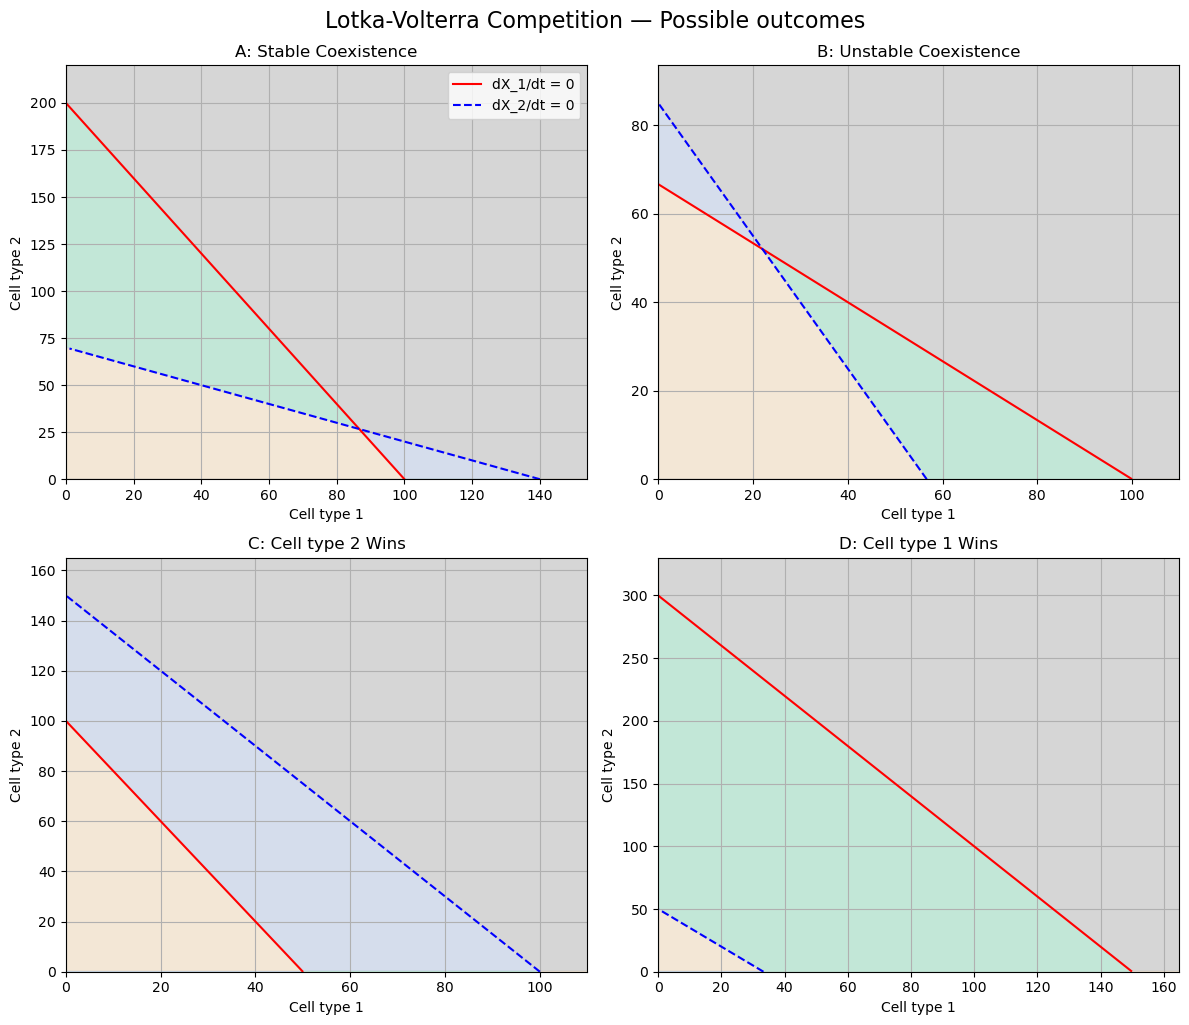

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def plot_clean_case(ax, K1, K2, alpha, beta, title):
    r1 = r2 = 1

    # Dynamically set axis limits to the maximum required
    x_max_nc = K2 / beta
    y_max_nc = K1 / alpha
    x_max = max(K1, x_max_nc) * 1.1
    y_max = max(K2, y_max_nc) * 1.1

    x = np.linspace(0, x_max, 400)
    y = np.linspace(0, y_max, 400)
    X, Y = np.meshgrid(x, y)

    # Compute derivatives
    dxdt = r1 * X * (1 - (X + alpha * Y) / K1)
    dydt = r2 * Y * (1 - (Y + beta * X) / K2)

    # Determine region types
    region = np.zeros_like(X)
    region[(dxdt > 0) & (dydt > 0)] = 3
    region[(dxdt > 0) & (dydt < 0)] = 1
    region[(dxdt < 0) & (dydt > 0)] = 2
    region[(dxdt < 0) & (dydt < 0)] = 4

    # Plot shaded regions
    cmap = plt.get_cmap("Pastel2", 5)
    ax.contourf(X, Y, region, levels=[0.5, 1.5, 2.5, 3.5, 4.5], cmap=cmap, alpha=0.8)

    # Nullclines
    x_vals = np.linspace(0, x_max, 400)
    y1_nc = (K1 - x_vals) / alpha
    y1_nc[y1_nc < 0] = np.nan

    y_vals = np.linspace(0, y_max, 400)
    x2_nc = (K2 - y_vals) / beta
    x2_nc[x2_nc < 0] = np.nan

    ax.plot(x_vals, y1_nc, 'r-', label='dX_1/dt = 0')
    ax.plot(x2_nc, y_vals, 'b--', label='dX_2/dt = 0')

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)
    ax.set_xlabel("Cell type 1")
    ax.set_ylabel("Cell type 2")
    ax.set_title(title)
    ax.grid(True)

# Define 4 biological outcome cases
cases = [
    {
        "K1": 100, "K2": 70,
        "alpha": 0.5, "beta": 0.5,
        "title": "A: Stable Coexistence"
    },
    {
        "K1": 100, "K2": 85,
        "alpha": 1.5, "beta": 1.5,
        "title": "B: Unstable Coexistence"
    },
    {
        "K1": 50, "K2": 150,
        "alpha": 0.5, "beta": 1.5,
        "title": "C: Cell type 2 Wins"
    },
    {
        "K1": 150, "K2": 50,
        "alpha": 0.5, "beta": 1.5,
        "title": "D: Cell type 1 Wins"
    }
]


# Plot all cases in a 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, case in zip(axes.flat, cases):
    plot_clean_case(ax, **case)

axes[0, 0].legend(loc='upper right')

plt.tight_layout()
plt.suptitle("Lotka-Volterra Competition — Possible outcomes", fontsize=16, y=1.02)
plt.show()



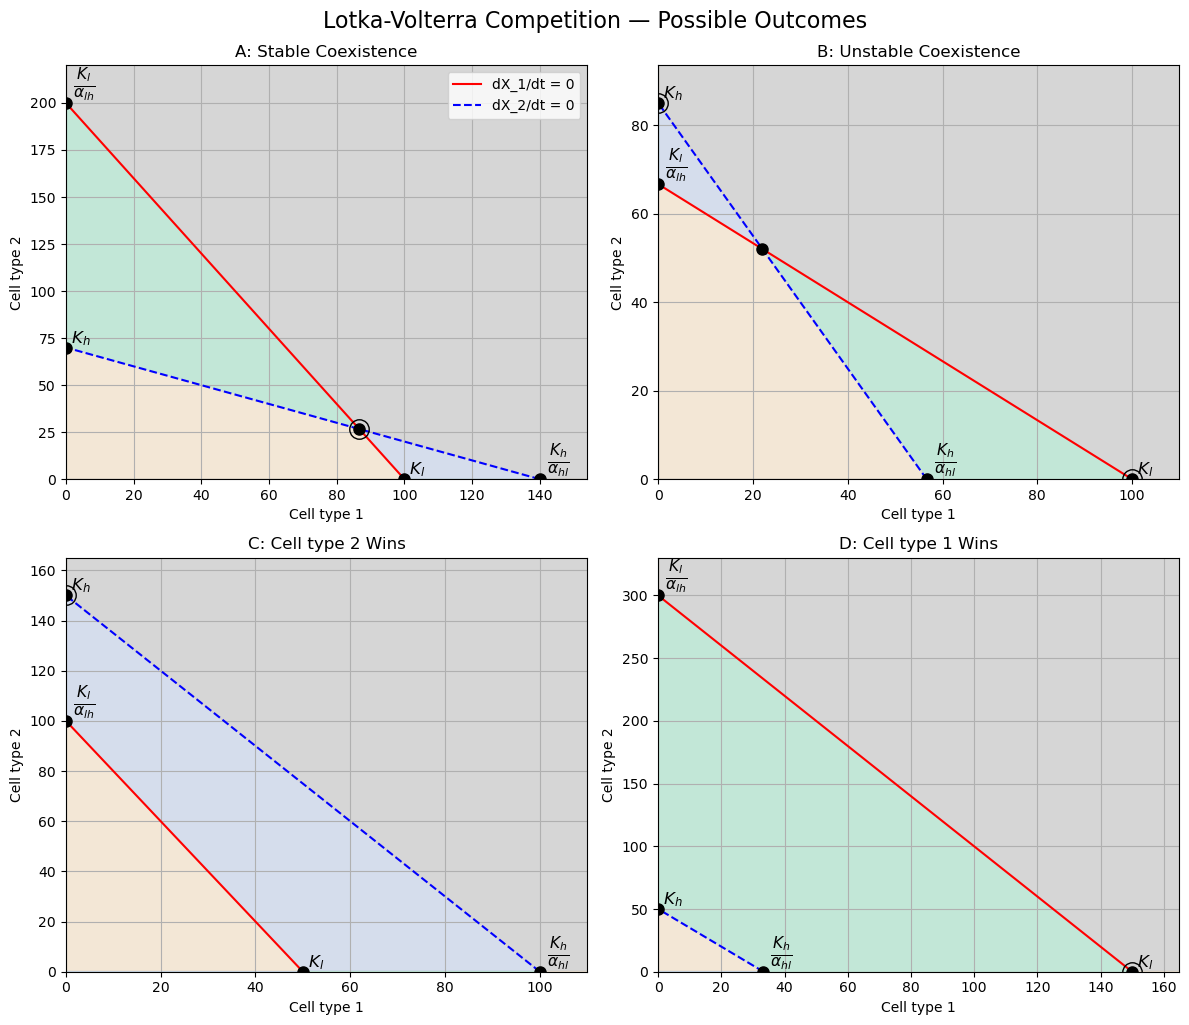

In [71]:
import numpy as np
import matplotlib.pyplot as plt

def plot_clean_case(ax, K1, K2, alpha, beta, title):
    r1 = r2 = 1

    # Dynamically set axis limits to the maximum required
    x_max_nc = K2 / beta
    y_max_nc = K1 / alpha
    x_max = max(K1, x_max_nc) * 1.1
    y_max = max(K2, y_max_nc) * 1.1

    x = np.linspace(0, x_max, 400)
    y = np.linspace(0, y_max, 400)
    X, Y = np.meshgrid(x, y)

    # Compute derivatives
    dxdt = r1 * X * (1 - (X + alpha * Y) / K1)
    dydt = r2 * Y * (1 - (Y + beta * X) / K2)

    # Determine region types
    region = np.zeros_like(X)
    region[(dxdt > 0) & (dydt > 0)] = 3
    region[(dxdt > 0) & (dydt < 0)] = 1
    region[(dxdt < 0) & (dydt > 0)] = 2
    region[(dxdt < 0) & (dydt < 0)] = 4

    # Plot shaded regions
    cmap = plt.get_cmap("Pastel2", 5)
    ax.contourf(X, Y, region, levels=[0.5, 1.5, 2.5, 3.5, 4.5], cmap=cmap, alpha=0.8)

    # Nullclines
    x_vals = np.linspace(0, x_max, 400)
    y1_nc = (K1 - x_vals) / alpha
    y1_nc[y1_nc < 0] = np.nan

    y_vals = np.linspace(0, y_max, 400)
    x2_nc = (K2 - y_vals) / beta
    x2_nc[x2_nc < 0] = np.nan

    ax.plot(x_vals, y1_nc, 'r-', label='dX_1/dt = 0')
    ax.plot(x2_nc, y_vals, 'b--', label='dX_2/dt = 0')

    # Add markers for key points with labels
    ax.plot(K1, 0, 'ko',markersize=8)  # K1
    ax.text(K1, 0, ' $K_l$', fontsize=12, verticalalignment='bottom', horizontalalignment='left')

    ax.plot(0, K2, 'ko', markersize=8)  # K2
    ax.text(0, K2, ' $K_h$', fontsize=12, verticalalignment='bottom', horizontalalignment='left')

    ax.plot(K2 / beta, 0, 'ko', markersize=8)  # K2 / beta
    ax.text(K2 / beta, 0, r' $\frac{K_h}{\alpha_{hl}}$', fontsize=16, verticalalignment='bottom', horizontalalignment='left')

    ax.plot(0, K1 / alpha, 'ko', markersize=8)  # K1 / alpha
    ax.text(0, K1 / alpha, r' $\frac{K_l}{\alpha_{lh}}$', fontsize=16, verticalalignment='bottom', horizontalalignment='left')

    
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)
    ax.set_xlabel("Cell type 1")
    ax.set_ylabel("Cell type 2")
    ax.set_title(title)
    ax.grid(True)
    
    # Compute fixed point (intersection of nullclines)
    denom = 1 - alpha * beta
    if denom != 0:
      x_star = (K1 - alpha * K2) / denom
      y_star = (K2 - beta * K1) / denom

    if 0 <= x_star <= x_max and 0 <= y_star <= y_max:
        ax.plot(x_star, y_star, 'ko', markersize=8)#, label='fixed point')
    
        # Highlight specific points depending on the case
    if title.startswith("C"):
        # Mark K_h = K2
        ax.plot(0, K2, 'o', markersize=14, fillstyle='none', color='black', label="K_h")
        #ax.annotate("K$_h$", (0, K2), textcoords="offset points", xytext=(5, 5), fontsize=12)

    elif title.startswith("D"):
        # Mark K_l = K1
        ax.plot(K1, 0, 'o', markersize=14, fillstyle='none', color='black', label="K_l")
        #ax.annotate("K$_l$", (K1, 0), textcoords="offset points", xytext=(5, 5), fontsize=12)

    elif title.startswith("A") and 0 <= x_star <= x_max and 0 <= y_star <= y_max:
        # Circle equilibrium point in Case A
        ax.plot(x_star, y_star, 'o', markersize=14, fillstyle='none', color='black')
        #ax.annotate("Equilibrium", (x_star, y_star), textcoords="offset points", xytext=(5, 5), fontsize=12)
        
    elif title.startswith("B") and 0 <= x_star <= x_max and 0 <= y_star <= y_max:
        # Circle equilibrium point in Case A
        ax.plot(K1, 0, 'o', markersize=14, fillstyle='none', color='black', label="K_l")
        ax.plot(0, K2, 'o', markersize=14, fillstyle='none', color='black', label="K_h")
        #ax.annotate("Equilibrium", (x_star, y_star), textcoords="offset points", xytext=(5, 5), fontsize=12)
# Define 4 biological outcome cases
cases = [
    {
        "K1": 100, "K2": 70,
        "alpha": 0.5, "beta": 0.5,
        "title": "A: Stable Coexistence"
    },
    {
        "K1": 100, "K2": 85,
        "alpha": 1.5, "beta": 1.5,
        "title": "B: Unstable Coexistence"
    },
    {
        "K1": 50, "K2": 150,
        "alpha": 0.5, "beta": 1.5,
        "title": "C: Cell type 2 Wins"
    },
    {
        "K1": 150, "K2": 50,
        "alpha": 0.5, "beta": 1.5,
        "title": "D: Cell type 1 Wins"
    }
]

# Plot all cases in a 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, case in zip(axes.flat, cases):
    plot_clean_case(ax, **case)

axes[0, 0].legend(loc='upper right')

plt.tight_layout()
plt.suptitle("Lotka-Volterra Competition — Possible Outcomes", fontsize=16, y=1.02)
plt.show()
